Importamos librerias necesarias

In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_train = pd.read_csv("Train.csv")
data_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Que podemos ver de las columnas que nos indica el dataset de entrenamiento es que;

PassengerId ==> ID del pasajero<br>
Survived ==> Si sobrevivió o no<br>
Pclass ==> Clase del Pasajero<br>
Name => Nombre del pasajero<br>
Sex ==> Género<br>
age ==> edad<br>
SibSp ==> No lo se<br>
Parch ==> Tampoco<br>
Ticket ==> Boleto boleto<br>
Fare ==> Tarifa<br>
Cabin ==> cabina<br>
Embarked ==> Puerto de embarque

Ahora veré que tipo de datos son esta información;

In [10]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


¿Qué podemos ver en esta información que sea relevante? 

Nos dice que hay un total de 891 pasajeros en los datos de entrenamiento, pero tenemos datos incompletos para algunos columnas, como por ejemplo:

- La columna de edad se registra solo para 714 pasajeros

Con esto sabido podemos dejar en vista otro tipo de información de los mismos datos que serían su distribución con el comando describe, este solo tomaria en cuenta las columnas que sean  tipo entero ya que las que son tipo objeto no es posible tomarlas en cuenta.

In [13]:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Que es chocante de esta información, es la media de supervivientes que nos indica que de 891 pasajeros sobrevivió el 0.3838 de la tripulación. También podemos ver la edad que nos presenta una media de 29 años, con edades entre los 0.42 años a los 80 años. Esto nos da mucho ruido, se necesita analizar a mucho más detalle la información, probaremos viendo la relación de sobreviviente con las demás columnas.

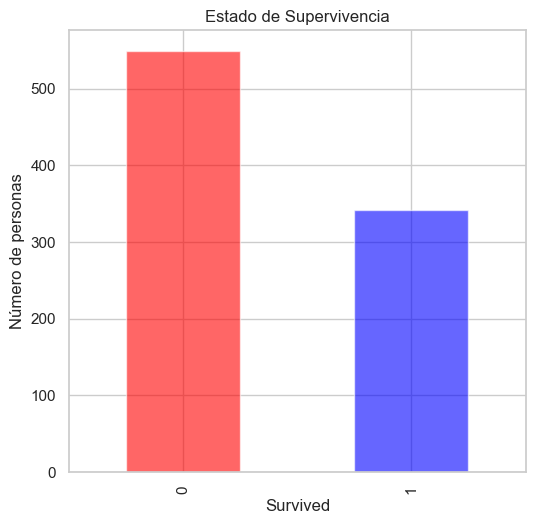

In [37]:
fig = plt.figure(figsize=(15, 10))
fig.set_alpha(0.2)

# Distribución de sobrevivientes
plt.subplot2grid((2,3),(0,0))
data_train.Survived.value_counts().plot(kind='bar', color=['red', 'blue'], alpha=0.6)
plt.title("Estado de Supervivencia")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

Viendo esta información que nos entrega la cantidad de personas que sobrevivieron realmente, me sigue haciendo ruido ya que al hundimiento del Titanic al buscar en internet me daba que sobrevivieron en total entre 706 a 712 personas, y esto se puede apreciar que no supera las 350 personas :/, lo otro que no está visto es la clase que estaban en la tripulación para ver si los que estaban más acomodados tuvieron más oportunidades de sobreviviencia que los que compraron el ticket más bárato. Primero identificar como está construida la columnna de Pclass.

In [42]:
print(data_train['Pclass'].unique())

[3 1 2]


Esto visto de manera intuitiva nos indica que;
- 1 ==> Primera Clase
- 2 ==> Segunda Clase
- 3 ==> Tercera Clase

C:\Users\fabia\AppData\Local\Temp\ipykernel_2252\423073223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Pclass', data=solo_sobrevivientes, palette='viridis')


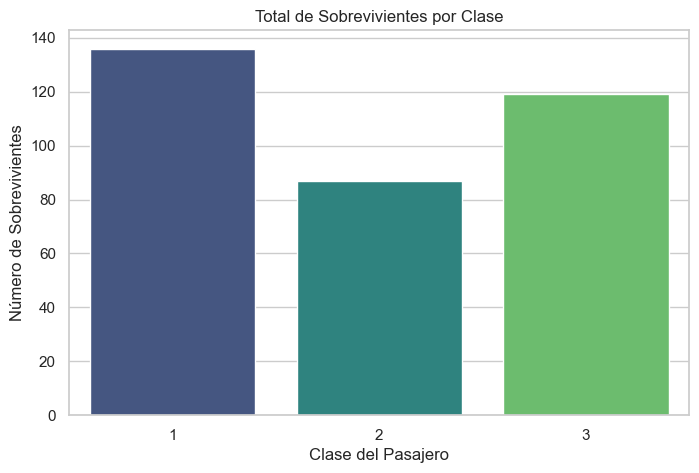

In [46]:
solo_sobrevivientes = data_train[data_train['Survived'] == 1]

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Pclass', data=solo_sobrevivientes, palette='viridis')

plt.title('Total de Sobrevivientes por Clase')
plt.xlabel('Clase del Pasajero')
plt.ylabel('Número de Sobrevivientes')

plt.show()

Osea que sí fueron los con el ticket más caro los que sobrevivieron, pero para que sea más clasista aún, vamos a ver la distribución de los que estaban en cada clase,

C:\Users\fabia\AppData\Local\Temp\ipykernel_2252\3676820129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Pclass', data=data_train, palette='viridis')


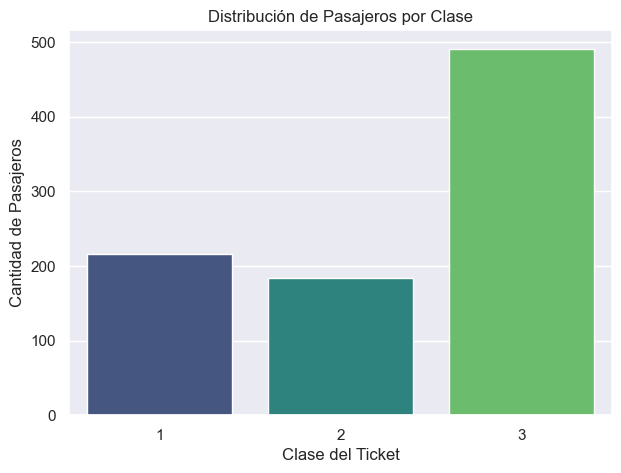

In [48]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(7, 5))

# Creamos el gráfico de conteo
ax = sns.countplot(x='Pclass', data=data_train, palette='viridis')

plt.title('Distribución de Pasajeros por Clase')
plt.xlabel('Clase del Ticket')
plt.ylabel('Cantidad de Pasajeros')

plt.show()

# :O

Ahora no se que más hacer, pero bueno, estos datos de entrenamiento no están del todo correctos, ni siquiera en el total está bien, ya que fueron 2200 personas como mínimo que se encontraban en la tripulación, esto en base a lo encontrado en internet de una fuente lo suficientemente confiable.

Fuente: https://historia.nationalgeographic.com.es/a/vidas-truncadas-titanic_11387